<a href="https://colab.research.google.com/github/giugnom3/Algorithms/blob/main/W5_HW_GiugnoMaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Boston Housing Dataset**

Import Libraries

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, model_selection
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Load Dataset

In [68]:
df = pd.read_csv("BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


Rename Columns and Select Required Features

In [84]:
df = df.rename(columns={
    "medv": "Target",
    "rm": "RM",
    "lstat": "LSTAT"
})

df = df[["RM", "LSTAT", "Target"]]

df.head()

,RM,LSTAT,Target
0,6.575,4.98,24.0
1,6.421,9.14,21.6
2,7.185,4.03,34.7
3,6.998,2.94,33.4
4,7.147,5.33,36.2


Visualize Relationships

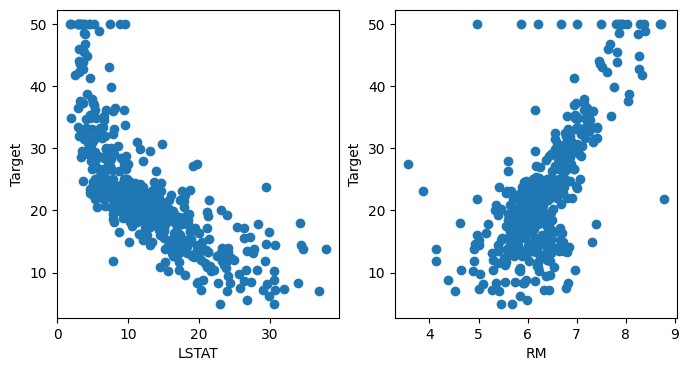

In [70]:
plt.figure(figsize=(8,4))

features = df[["LSTAT", "RM"]]
target = df["Target"]


plt.subplot(1,2,1)
plt.scatter(df["LSTAT"], target)
plt.xlabel("LSTAT")
plt.ylabel("Target")

plt.subplot(1,2,2)
plt.scatter(df["RM"], target)
plt.xlabel("RM")
plt.ylabel("Target")

plt.show()

Split into Training and Testing Sets

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=23
)

Train Linear Regression Model

In [72]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Make Predictions

In [73]:
y_pred = model.predict(X_test)

Create Visualization

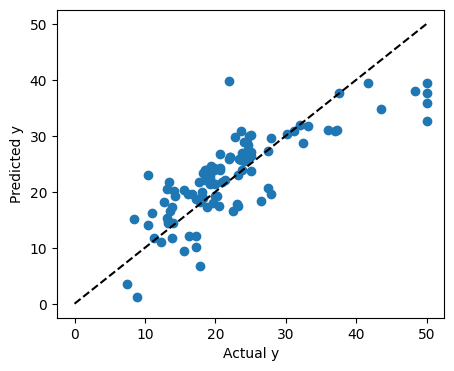

In [85]:
from scipy.optimize._lsq.common import intersect_trust_region

plt.figure(figsize=(5,4))
plt.scatter(y_test, y_pred)
plt.plot([0, 50], [0, 50], '--k', label= "Correct Prediction")
plt.xlabel("Actual y")
plt.ylabel("Predicted y")

plt.show()


In [75]:
intercept = model.intercept_
coff = model.coef_

In [76]:
intercept

np.float64(0.37428615187841885)

In [77]:
coff

array([-0.66721079,  4.88331552])

Evaluate the Model

In [78]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Square Error:", mse)
print("Mean Absolute Error:", mae)
print("R2:", r2)

Mean Square Error: 30.726065211573893
Mean Absolute Error: 4.300122669036365
R2: 0.6433023932639312


In [79]:
new_houses_data ={
    "LSTAT": [5.0, 4.0, 15.0],
    "RM": [7, 6, 8]
}

new_houses_df = pd.DataFrame(new_houses_data)
new_houses_df

,LSTAT,RM
0,5.0,7
1,4.0,6
2,15.0,8


In [80]:
predicted_houses_prices = model.predict(new_houses_df)
predicted_houses_prices

array([31.22144086, 27.00533613, 29.43264846])

In [81]:
new_houses_df["Predicted Price"] = predicted_houses_prices
new_houses_df

,LSTAT,RM,Predicted Price
0,5.0,7,31.221441
1,4.0,6,27.005336
2,15.0,8,29.432648
